# Sentiment Analysis Project

In [1]:
import pandas as pd
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
df = pd.read_csv("../Data/cleaned_sentiment_data.csv")

print("Cleaned dataset loaded successfully!")
print(f"Shape: {df.shape}")
print("Columns:", df.columns.tolist())
df.head()

Cleaned dataset loaded successfully!
Shape: (49582, 4)
Columns: ['review', 'sentiment', 'clean_review', 'sentiment_encoded']


,review,sentiment,clean_review,sentiment_encoded
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production the filming tech...,1
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,negative,basically theres a family where a little boy j...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love in the time of money is a ...,1


In [3]:
model = joblib.load("../models/sentiment_model.pkl")
vectorizer = joblib.load("../models/tfidf_vectorizer.pkl")

print("Model and Vectorizer loaded successfully!")

Model and Vectorizer loaded successfully!


In [4]:
X_test = vectorizer.transform(df['clean_review'])
y_test = df['sentiment']

y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print(f"Number of test samples: {len(y_test)}")

Predictions generated successfully!
Number of test samples: 49582


In [5]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Model Accuracy: 0.9052 (90.52%)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.92      0.89      0.90     24698
    Positive       0.89      0.93      0.91     24884

    accuracy                           0.91     49582
   macro avg       0.91      0.91      0.91     49582
weighted avg       0.91      0.91      0.91     49582



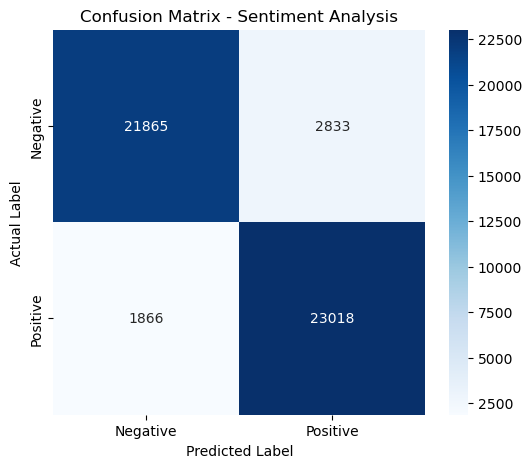

In [6]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix - Sentiment Analysis')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [7]:
import os
os.makedirs("../models", exist_ok=True)

joblib.dump(model, "../models/sentiment_model.pkl")
joblib.dump(vectorizer, "../models/tfidf_vectorizer.pkl")

print("Best model and vectorizer saved successfully!")
print("Files saved in '../models/' folder")

Best model and vectorizer saved successfully!
Files saved in '../models/' folder
